In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [19]:
from astropy import units as un, constants as cons
import numpy as np
import cooling_flow as CF
import HaloPotential as Halo
import matplotlib.pyplot as plt
import GrackleCooling as Cool
import AgoraPotential as Agora
import glob,h5py
from scipy.interpolate import RegularGridInterpolator

In [209]:
plt.rcParams['font.size']=18
plt.rcParams['axes.linewidth']=2
plt.rcParams['xtick.major.size']=10
plt.rcParams['xtick.minor.size']=5
plt.rcParams['xtick.major.width']=2
plt.rcParams['xtick.minor.width']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.major.size']=10
plt.rcParams['ytick.minor.size']=5
plt.rcParams['ytick.major.width']=2
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.direction']='in'

In [272]:
Msun = 1.988409870698051e+33
G = 6.674299999999999e-08
mp = 1.67262192369e-24
kpc = 3.0856775814913673e+21
gamma = 5./3.
yr_to_sec = 3.154e+7
Myr = yr_to_sec * 1.e6
kmps = 1.e5
kb = 1.38e-16
Z2Zsun = 1.

cloudy_H_mass_fraction = 1. / (1. + 0.1 * 3.971)
X = cloudy_H_mass_fraction
Z = 0.02  # metal fraction by mass
Y = 1. - X - Z
mean_metals_A = 16.  # mean atomic weight of metals
sigma_T = 6.6524e-25  
electron_mass_cgs = 9.1093897e-28  # electron mass (g)
mu = 0.6
m_H = 1.672623e-24  # g
T_cmb = 2.725  # * (1 + z); // K
c_light_cgs_ = 2.99792458e10  # cgs
radiation_constant_cgs_ = 7.5646e-15  # cgs
boltzmann_constant_cgs_ = 1.380658e-16  # cgs

In [122]:
mmw.shape, logTbins.shape

((29, 161), (161,))

In [133]:
logTbins

array([1.000000e+01, 1.122018e+01, 1.258925e+01, 1.412538e+01,
       1.584893e+01, 1.778279e+01, 1.995262e+01, 2.238721e+01,
       2.511886e+01, 2.818383e+01, 3.162278e+01, 3.548134e+01,
       3.981072e+01, 4.466836e+01, 5.011872e+01, 5.623413e+01,
       6.309573e+01, 7.079458e+01, 7.943282e+01, 8.912509e+01,
       1.000000e+02, 1.122018e+02, 1.258925e+02, 1.412538e+02,
       1.584893e+02, 1.778279e+02, 1.995262e+02, 2.238721e+02,
       2.511886e+02, 2.818383e+02, 3.162278e+02, 3.548134e+02,
       3.981072e+02, 4.466836e+02, 5.011872e+02, 5.623413e+02,
       6.309573e+02, 7.079458e+02, 7.943282e+02, 8.912509e+02,
       1.000000e+03, 1.122018e+03, 1.258925e+03, 1.412538e+03,
       1.584893e+03, 1.778279e+03, 1.995262e+03, 2.238721e+03,
       2.511886e+03, 2.818383e+03, 3.162278e+03, 3.548134e+03,
       3.981072e+03, 4.466836e+03, 5.011872e+03, 5.623413e+03,
       6.309573e+03, 7.079458e+03, 7.943282e+03, 8.912509e+03,
       1.000000e+04, 1.122018e+04, 1.258925e+04, 1.4125

In [198]:
10**lognHbins[10], 10**lognHbins[20]

(np.float64(1e-05), np.float64(1.0))

In [202]:
net_metprim_heating[idx2]/net_metprim_heating[idx3]

array([1.95599504e-02, 1.86614376e-02, 1.77741564e-02, 1.68991127e-02,
       1.60889080e-02, 1.53350612e-02, 1.45683276e-02, 1.38684043e-02,
       1.31915770e-02, 1.25337591e-02, 1.18977836e-02, 1.12788129e-02,
       1.06916623e-02, 1.01127603e-02, 9.52976036e-03, 8.97785960e-03,
       8.44188788e-03, 7.91730103e-03, 7.41558419e-03, 6.95286249e-03,
       6.47213427e-03, 6.01701748e-03, 5.59708711e-03, 5.20597242e-03,
       4.83248331e-03, 4.49814772e-03, 4.19021476e-03, 3.91306573e-03,
       3.66401052e-03, 3.44394776e-03, 3.25463107e-03, 3.09505695e-03,
       2.95377151e-03, 2.83851550e-03, 2.74412774e-03, 2.66809248e-03,
       2.59705008e-03, 2.53748593e-03, 2.48672273e-03, 2.43216460e-03,
       2.38211434e-03, 2.32468740e-03, 2.26208483e-03, 2.18700557e-03,
       2.10366582e-03, 2.01093791e-03, 1.90695404e-03, 1.79552907e-03,
       1.67808741e-03, 1.55162173e-03, 1.42074128e-03, 1.29004101e-03,
       1.15401184e-03, 1.02067042e-03, 8.91366429e-04, 7.69016682e-04,
      

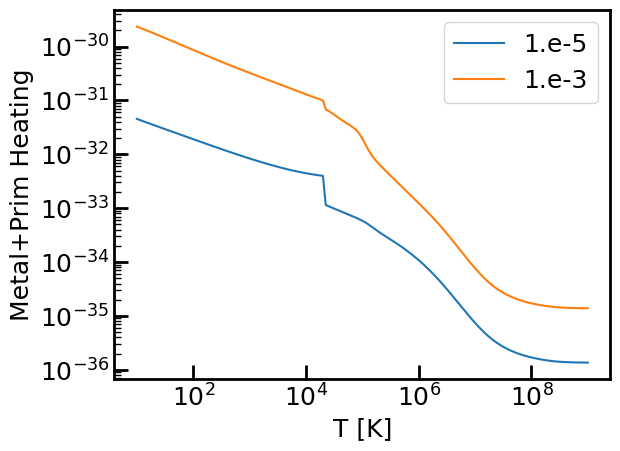

In [237]:
filename = "/Users/aditivijayan/quokka/INCITE/dwGal_setup/HaloProfile/cooling_flow_stern-19/GalaxyIC_for_Quokka/CloudyData_UVB=HM2012_shielded.h5"
with h5py.File(filename, "r") as f:
    metal_heating = f["CoolingRates/Metals/Heating"][:,0,:]
    primordial_heating = f["CoolingRates/Primordial/Heating"][:,0,:]
    lognHbins = f['CoolingRates/Metals/Cooling'].attrs['Parameter1']
    Tbins = f['CoolingRates/Metals/Cooling'].attrs['Temperature']

nHgrid,  Tgrid = np.meshgrid(10.** lognHbins, Tbins, indexing='ij')
net_metprim_heating =  nHgrid ** 2 * (metal_heating + primordial_heating)

idx1 = 10 #1.e-5
idx2 = 12 #1.e-3
idx3 = 20 #1.0
plt.plot(Tbins, net_metprim_heating[idx1], label='1.e-5')
plt.plot(Tbins, net_metprim_heating[idx2], label='1.e-3')

plt.xscale('log')
plt.xlabel('T [K]')
plt.ylabel('Metal+Prim Heating')
plt.legend(loc='upper right')
plt.yscale('log')
# plt.ylim(1.e-7, 10.0)


In [273]:
filename = "/Users/aditivijayan/quokka/INCITE/dwGal_setup/HaloProfile/cooling_flow_stern-19/GalaxyIC_for_Quokka/CloudyData_UVB=HM2012_shielded.h5"
with h5py.File(filename, "r") as f:
    metal_cooling = f["CoolingRates/Metals/Cooling"][:,0,:]
    metal_heating = f["CoolingRates/Metals/Heating"][:,0,:]
    primordial_cooling = f["CoolingRates/Primordial/Cooling"][:,0,:]
    primordial_heating = f["CoolingRates/Primordial/Heating"][:,0,:]
    mu = f["CoolingRates/Primordial/MMW"][:, 0, :]
    lognHbins = f['CoolingRates/Metals/Cooling'].attrs['Parameter1']
    Tbins = f['CoolingRates/Metals/Cooling'].attrs['Temperature']


nHgrid,  Tgrid = np.meshgrid(10.** lognHbins, Tbins, indexing='ij')
net_metalprim_cooling_rate =  (Z2Zsun*(metal_cooling - metal_heating) + (primordial_cooling - primordial_heating))
net_cooling_rate = nHgrid ** 2 * (net_metalprim_cooling_rate[:])
net_metprim_cooling =  nHgrid ** 2 * (metal_cooling + primordial_cooling)
net_metprim_heating =  nHgrid ** 2 * (metal_heating + primordial_heating)



rhoHgrid = nHgrid* m_H
rho = rhoHgrid / cloudy_H_mass_fraction


#Photoelectric Cooling Rate
n_e = (rho / m_H) * \
                 (1.0 - mu * (X + Y / 4. + Z / mean_metals_A)) / \
                 (mu - ( electron_mass_cgs / m_H))

n_e = np.maximum(n_e, 1.e-4 * nHgrid)
Tsqrt = np.sqrt(Tgrid)
phi = 0.5  # phi_PAH from Wolfire et al. (2003)
G_0 = 1.7  # ISRF from Wolfire et al. (2003)
epsilon = \
4.9e-2 / (1. + 4.0e-3 * (G_0 * Tsqrt / (n_e * phi))**0.73) + \
3.7e-2 * (Tgrid / 1.0e4)**(0.7) / \
    (1. + 2.0e-4 * (G_0 * Tsqrt / (n_e * phi)))
Gamma_pe = 1.3e-24 * nHgrid * epsilon * G_0
cooling_rate_PE = -1. * (Gamma_pe)  #/ nHgrid ** 2

#Compton Cooling
E_cmb = radiation_constant_cgs_ * (T_cmb * T_cmb * T_cmb * T_cmb)
Gamma_C = (8. * sigma_T * E_cmb) / (3. * cons.m_e.value * c_light_cgs_)
C_n     = Gamma_C * boltzmann_constant_cgs_ / (5. / 3. - 1.0)
compton_CMB =  (-C_n * (Tgrid - T_cmb) * n_e)  #/ nHgrid ** 2)

net_lambda = (net_cooling_rate + cooling_rate_PE + compton_CMB)

In [274]:
net_PE =  -cooling_rate_PE 
net_CMB = - compton_CMB 

In [275]:
interp_net_PE = RegularGridInterpolator((lognHbins, np.log10(Tbins)), np.log10(net_PE))
interp_net_CMB = RegularGridInterpolator((lognHbins, np.log10(Tbins)), np.log10(net_CMB))
interp_net_metprim_cooling = RegularGridInterpolator((lognHbins, np.log10(Tbins)), np.log10(net_metprim_cooling))
interp_net_metprim_heating = RegularGridInterpolator((lognHbins, np.log10(Tbins)), np.log10(net_metprim_heating))

1.1356284750744836e-32 10.0
1.7054549787094864e-29 10.0


Text(0, 0.5, 'PE')

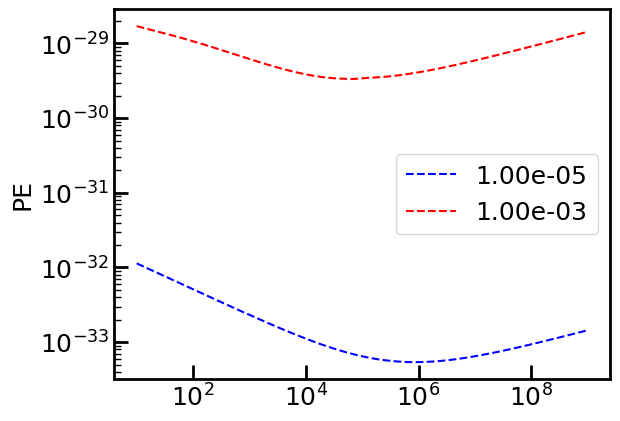

In [276]:
lam1_metprim_cooling = np.zeros(Tbins.shape[0])
lam2 = np.zeros(Tbins.shape[0])
nH = [1.e-5, 1.e-3]
ls = ['-', '--', ':']
color = ['blue', 'red', 'green']
i=0
for n in nH:
    # lam_metprim_cool = interp_net_metprim_cooling((np.log10(Tbins), np.log10(n)))
    # lam_metprim_heating = interp_net_metprim_heating((np.log10(n), np.log10(Tbins)))
    lam_PE = interp_net_PE((np.log10(n), np.log10(Tbins) ))
    print(10.**lam_PE[0], Tbins[0])
    # lam_CMB = interp_net_CMB((np.log10(Tbins), np.log10(n)))
# 
    # plt.plot(Tbins, lam_metprim_cool, ls='-', color='blue', label = '%.2e'%(n))
    # plt.plot(Tbins, 10.**lam_metprim_heating/n, ls='--', color=color[i], label = '%.2e'%(n))
    plt.plot(Tbins, 10.**lam_PE, ls='--', color=color[i],label = '%.2e'%(n))
    # plt.plot(Tbins, lam_CMB, ls='-.', color='green')
    i+=1
plt.legend()
plt.xscale('log')    
plt.yscale('log')    
plt.ylabel('PE')
# plt.ylim(-36, -25)

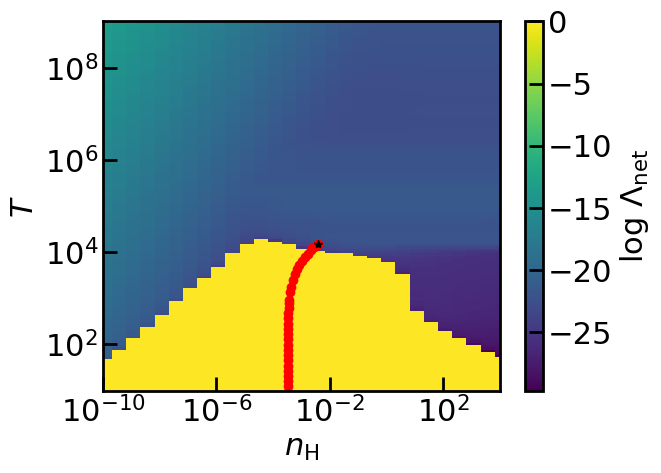

In [39]:
plt.figure()
net_lambda[net_lambda<0.0] = 1.
plt.pcolormesh(nHbins, Tbins, np.log10(net_lambda), shading='auto')
plt.colorbar(label=r'log $\Lambda_{\rm net}$')
plt.xlabel(r'$n_{\rm H}$')
plt.xlim(1.e-10, 1.e4)
plt.ylabel(r'$T$')
plt.xscale('log')
plt.yscale('log')
plt.plot(nH1, T1, 'o', color='red')
plt.plot(0.0039391173191453055, 1.46688984e+04, '*', color='black')
plt.show()

In [25]:
# nH1 = np.asarray([0.00393912, 0.00355138, 0.00325603, 0.00277221, 0.00242883,
#        0.0021548 , 0.0016488 , 0.00130094, 0.00104569, 0.00085186,
#        0.00070165, 0.00058387, 0.00049091, 0.00041733, 0.00038993,
#        0.00036508, 0.00035745, 0.00034998, 0.00034456, 0.0003405 ,
#        0.0003378 , 0.00033605, 0.0003347 , 0.00033381, 0.00033314,
#        0.00033271, 0.00033239, 0.00033215, 0.00033198, 0.00033185,
#        0.00033176, 0.00033169, 0.00033164, 0.0003316 , 0.00033158,
#        0.00033156, 0.00033154, 0.00033153, 0.00033152, 0.00033151,
#        0.00033151, 0.0003315 , 0.0003315 , 0.0003315 , 0.0003315 ,
#        0.0003315 , 0.0003315 , 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149,
#        0.00033149, 0.00033149, 0.00033149, 0.00033149, 0.00033149])

# T1 = np.asarray([1.46688984e+04, 1.43188606e+04, 1.38970379e+04, 1.29044764e+04,
#        1.19834142e+04, 1.11151353e+04, 9.19791877e+03, 7.63177139e+03,
#        6.32335239e+03, 5.20433728e+03, 4.22282528e+03, 3.34137837e+03,
#        2.52273858e+03, 1.71607384e+03, 1.34076743e+03, 9.27192974e+02,
#        7.76446429e+02, 6.11382104e+02, 4.75844335e+02, 3.61011268e+02,
#        2.75548701e+02, 2.14191213e+02, 1.62608901e+02, 1.25096282e+02,
#        9.48996150e+01, 7.38090036e+01, 5.69897704e+01, 4.37061270e+01,
#        3.35317735e+01, 2.59971701e+01, 2.00719843e+01, 1.53974476e+01,
#        1.18230810e+01, 9.07970121e+00, 6.97764085e+00, 5.36192821e+00,
#        4.12608133e+00, 3.18074708e+00, 2.45860106e+00, 1.90691261e+00,
#        1.48543192e+00, 1.16329152e+00, 9.17003431e-01, 7.13444787e-01,
#        5.50938635e-01, 4.22039084e-01, 3.21057599e-01, 2.42636163e-01,
#        1.82260137e-01, 1.36128523e-01, 1.01129800e-01, 7.47497542e-02,
#        5.49867250e-02, 4.02649711e-02, 2.93571016e-02, 2.13157841e-02,
#        1.54159686e-02, 1.11069366e-02, 7.97331350e-03, 5.70383045e-03,
#        4.06663665e-03, 2.89000754e-03, 2.04742374e-03, 1.44613474e-03,
#        1.01846537e-03, 7.15256557e-04, 5.00950294e-04, 3.49930362e-04,
#        2.43813455e-04, 1.69455587e-04, 1.17491789e-04, 8.12722666e-05,
#        5.60903971e-05, 3.86254069e-05, 2.65412488e-05, 1.81994487e-05,
#        1.24539244e-05, 8.50527501e-06, 5.79726497e-06, 3.94399215e-06,
#        2.67819787e-06, 1.81535739e-06, 1.22833900e-06, 8.29681445e-07,
#        5.59480553e-07, 3.76614894e-07, 2.53163525e-07, 1.69856499e-07,
#        1.13827132e-07, 7.61361974e-08, 5.08470019e-08, 3.39378629e-08,
#        2.25670264e-08, 1.50122281e-08, 9.99676120e-09, 6.61389623e-09,
#        4.41439285e-09, 2.92370075e-09, 1.93288949e-09, 1.28134387e-09])

In [106]:
1e-2*3.108e18**2/Msun

48.57984333284807